<center><img src="images/clothing.jpg"></center>

Welcome to the world of e-commerce, where customer feedback is a goldmine of insights! In this project, you'll dive into the Women's Clothing E-Commerce Reviews dataset, focusing on the 'Review Text' column filled with direct customer opinions.

Your mission is to use text embeddings and Python to analyze these reviews, uncover underlying themes, and understand customer sentiments. This analysis will help improve customer service and product offerings.

## The Data

You will be working with a dataset specifically focusing on customer reviews. Below is the data dictionary for the relevant field:

## womens_clothing_e-commerce_reviews.csv

| Column        | Description                           |
|---------------|---------------------------------------|
| `'Review Text'` | Textual feedback provided by customers about their shopping experience and product quality. |

Armed with access to powerful embedding API services, you will process the reviews, extract meaningful insights, and present your findings.

Let's get started!

## Install useful libraries

In [137]:
# Run this cell to install ChromaDB if desired
try:
    assert version('chromadb') == '0.4.17'
except:
    !pip install chromadb==0.4.17
try:
    assert version('pysqlite3') == '0.5.2'
except:
    !pip install pysqlite3-binary==0.5.2
__import__('pysqlite3')
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')
import chromadb

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


## Load the dataset
Load data and perform basic data checks to ensure you are using relevant data for the analysis

In [138]:
# Load the dataset
import pandas as pd
reviews = pd.read_csv("womens_clothing_e-commerce_reviews.csv")

# Display the first few entries
reviews.head()

,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [139]:
from openai import OpenAI
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

In [140]:
openai_client = OpenAI()

In [141]:
# extract non empty review text entries
reviews_clean = reviews.dropna(subset='Review Text', inplace=False)

In [142]:
# sanity check
assert reviews_clean['Review Text'].isna().sum() == 0

In [143]:
# compute embeddings for a list of text strings
def get_embeddings(texts, model="text-embedding-3-small"):
    response = openai_client.embeddings.create(
        input = texts,
        model = model)
    
    return [entry.embedding for entry in response.data]

In [144]:
embeddings = get_embeddings(reviews_clean['Review Text'])

In [145]:
# sanity check
assert len(reviews_clean) == len(embeddings)

In [146]:
# apply dimensionality reduction to the embeddings
tsne = TSNE(n_components=2, perplexity=5)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

In [147]:
# sanity check
assert len(embeddings_2d) == len(reviews_clean)

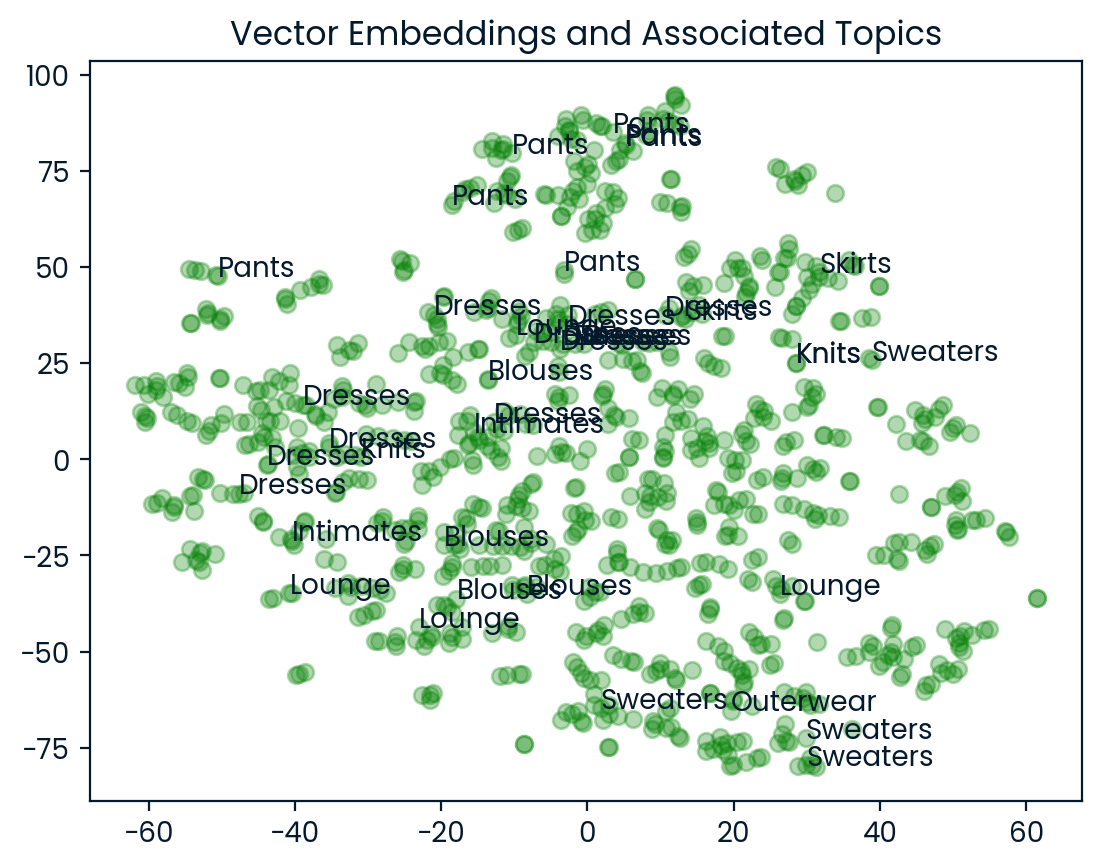

In [148]:
# visualize the embeddings and associated topics
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], color='green', alpha=0.3)

plt.title("Vector Embeddings and Associated Topics")

for i, class_name in reviews_clean['Class Name'].head(40).items():
    plt.annotate(class_name, (embeddings_2d[i,0], embeddings_2d[i,1]))
    
plt.show()

In [149]:
import os
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

In [150]:
chroma_client = chromadb.PersistentClient("db")

In [151]:
collection = chroma_client.get_or_create_collection(
    name='reviews',
    embedding_function=OpenAIEmbeddingFunction(
        model_name="text-embedding-3-small",
        api_key=os.environ.get("OPENAI_API_KEY")
    )
)

In [152]:
collection.add(
    ids=reviews_clean['Review ID'].astype(str).to_list(),
    documents=reviews_clean['Review Text'].to_list()
)

In [153]:
search_terms = ["quality", "fit", "style", "comfort"]
search_results = collection.query(query_texts=search_terms, n_results=3)

In [154]:
for index, term in enumerate(search_terms):
    print(f"SEARCH TERM: {term}")
    print("RELATED DOCUMENTS:")
    print("\n----------------------\n".join(search_results['documents'][index]))
    print()

SEARCH TERM: quality
RELATED DOCUMENTS:
This top is soo pretty with a cool edge.
it looks and feels like really good quality.
----------------------
The jacket is great, the quality is very good and the fit too, the best part is how it looks !
----------------------
Perfect fit. did not lose its shape. thicker material. great quality for a great price. definitely  a wardrobe  staple. can be dressed up or down. work (business) appropriate. fits tts. for reference,  i am 5'0", 109lbs, and the 00 petite fits perfect. falls right above ankle like pictured. if they had more colours, i would get them too :)

SEARCH TERM: fit
RELATED DOCUMENTS:
Nice fit and flare style, not clingy at all. i got the grey color, petite large, fits perfect. will wear with tights/boots or booties. lots of color options to accessorize with.
----------------------
The fit on these pants is just right for me. i have curvy hips and a slender waste and legs. these pants don't gap in the back, as fitted pants often can

In [155]:
def find_similar_reviews(review, n=3):
    search_results = collection.query(query_texts=[review], n_results=3)
    return search_results['documents'][0]

In [156]:
review = reviews_clean.loc[0, 'Review Text']
most_similar_reviews = find_similar_reviews(review)

In [157]:
most_similar_reviews

['Absolutely wonderful - silky and sexy and comfortable',
 'Very comfortable and versatile. got lots of compliments.',
 'This is a very comfortable and sexy sleep dress, the way it drapes. i can see that the type of fabric is not suitable for out and about activities and can catch on snags, etc. very easily. once i relegated it to the nightgown category it became my favorite item to wear and lounge in.']